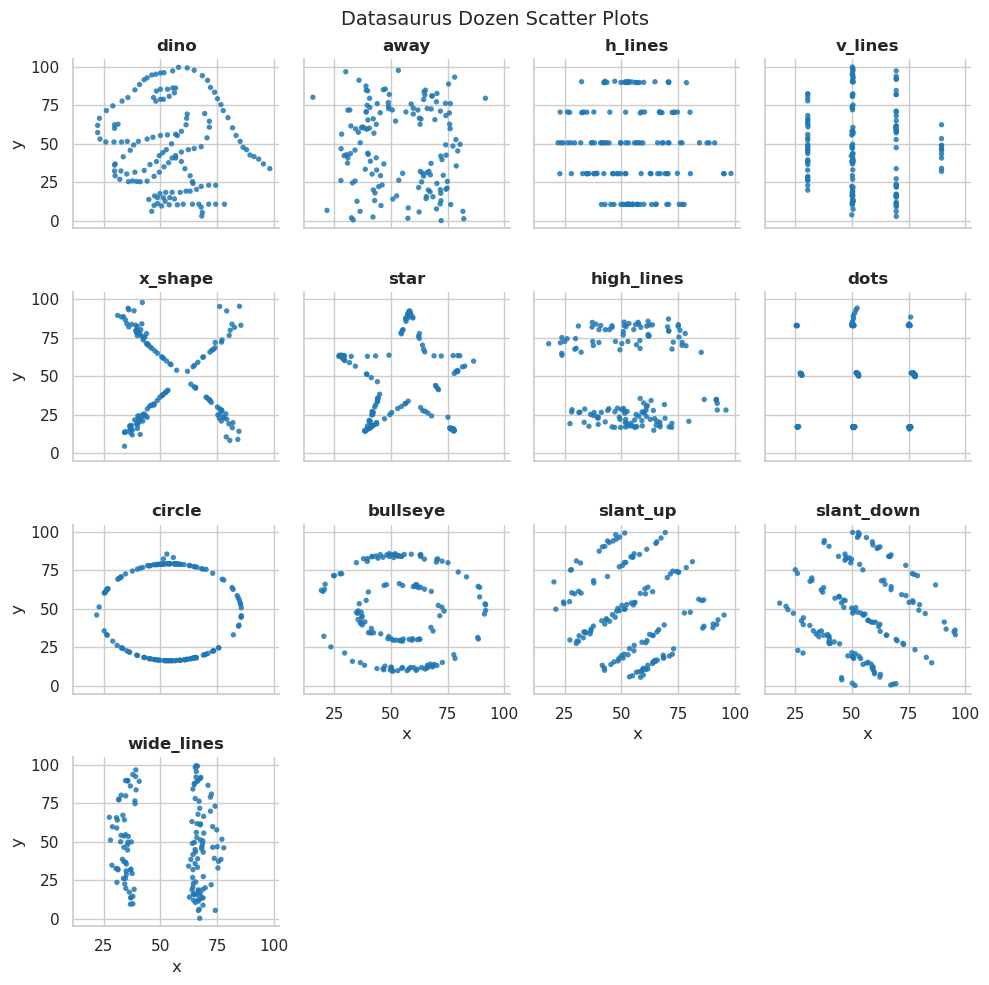

In [23]:
#Task 01
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Updated, working raw URL
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-13/datasaurus.csv"

# Load the dataset
df = pd.read_csv(url)

# Render the 13 scatter plots in a 4x4 grid
g = sns.FacetGrid(
    df, col="dataset", col_wrap=4, height=2.5, sharex=True, sharey=True
)
g.map(
    sns.scatterplot,
    "x",
    "y",
    s=15,
    color="#1f77b4",
    alpha=0.85,
    edgecolor="none",
)
g.set_titles(col_template="{col_name}", weight="bold")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Datasaurus Dozen Scatter Plots", fontsize=14)

plt.tight_layout()
plt.show()

Summary Statistics TableHere are the summary statistics for each of the 13 datasets in the Datasaurus Dozen ($N = 142$ points per dataset):
Dataset,Mean of X (xˉ),Mean of Y (yˉ​),Std Dev of X (sx​),Std Dev of Y (sy​),Pearson Correlation (r)
dino,54.26,47.83,16.76,26.94,-0.06
away,54.27,47.83,16.77,26.93,-0.06
bullseye,54.27,47.83,16.77,26.93,-0.07
circle,54.27,47.84,16.76,26.93,-0.07
dots,54.26,47.83,16.77,26.93,-0.06
h_lines,54.26,47.83,16.76,26.93,-0.06
high_lines,54.27,47.83,16.77,26.93,-0.07
slant_down,54.27,47.83,16.77,26.93,-0.07
slant_up,54.27,47.83,16.77,26.93,-0.07
star,54.27,47.83,16.77,26.93,-0.07
v_lines,54.27,47.83,16.77,26.93,-0.07
wide_lines,54.27,47.83,16.77,26.93,-0.07
x_shape,54.26,47.83,16.77,26.93,-0.07

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if gapminder is in seaborn or plotly datasets or download/load it
try:
    import plotly.express as px
    gapminder = px.data.gapminder()
    print("Gapminder loaded from plotly express successfully! Shape:", gapminder.shape)
except Exception as e:
    print("Plotly express failed:", e)
    # try loading from url or seaborn
    try:
        url = "https://raw.githubusercontent.com/resampling-stats/gapminder/master/gapminder.csv"
        gapminder = pd.read_csv(url)
        print("Loaded from URL! Shape:", gapminder.shape)
    except Exception as e2:
        print("URL failed:", e2)

Gapminder loaded from plotly express successfully! Shape: (1704, 8)


In [25]:
print(gapminder.columns.tolist())
print(gapminder.head())
print("Unique countries:", gapminder['country'].nunique())
print("Unique years:", gapminder['year'].unique())

['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap', 'iso_alpha', 'iso_num']
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  
Unique countries: 142
Unique years: [1952 1957 1962 1967 1972 1977 1982 1987 1992 1997 2002 2007]


In [26]:
# Let's inspect gdpPercap over time across percentiles / min-max / ratio
df = gapminder.copy()

summary_gdp = df.groupby('year')['gdpPercap'].agg(
    min_gdp='min',
    max_gdp='max',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90),
    median_gdp='median',
    ratio_90_10=lambda x: x.quantile(0.90) / x.quantile(0.10),
    ratio_max_min=lambda x: x.max() / x.min()
).reset_index()

print(summary_gdp)

    year     min_gdp       max_gdp         p10           p90   median_gdp  \
0   1952  298.846212  108382.35290  495.011137   7255.331025  1968.528344   
1   1957  335.997115  113523.13290  576.015003   9667.864702  2173.220291   
2   1962  355.203227   95458.11176  603.104765  10967.158195  2335.439533   
3   1967  349.000000   80894.88326  701.569504  14060.555369  2678.334741   
4   1972  357.000000  109347.86700  724.121055  16606.182211  3339.129407   
5   1977  371.000000   59265.47714  741.452427  19091.749553  3798.609244   
6   1982  424.000000   33693.17525  789.695848  19467.718923  4216.228428   
7   1987  385.000000   31540.97480  737.971793  21866.478894  4280.300366   
8   1992  347.000000   34932.91959  737.263173  24752.222324  4386.085502   
9   1997  312.188423   41283.16433  789.293399  26905.596049  4781.825478   
10  2002  241.165876   44683.97525  767.380378  29980.121701  5319.804524   
11  2007  277.551859   49357.19017  887.287056  33644.053012  6124.371109   

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn / matplotlib style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

# ---------------------------------------------------------
# Figure 1: Messy Spaghetti Chart
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.lineplot(data=gapminder, x='year', y='lifeExp', hue='country', legend='full')
plt.title("Life Expectancy Over Time (142 Countries) — The Messy 'Spaghetti' Chart", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)
# Place legend outside to demonstrate how huge it is
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=3, fontsize=6, title="Country")
plt.tight_layout()
plt.savefig("messy_spaghetti_chart.png", dpi=200)
plt.close()

# ---------------------------------------------------------
# Figure 2a: Aggregated by Continent
# ---------------------------------------------------------
cont_df = gapminder.groupby(['continent', 'year'])['lifeExp'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=cont_df, x='year', y='lifeExp', hue='continent', marker='o', linewidth=2.5, palette='tab10')
plt.title("Fix (a): Aggregated Life Expectancy by Continent (1952–2007)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mean Life Expectancy (Years)", fontsize=12)
plt.legend(title="Continent", frameon=True)
plt.tight_layout()
plt.savefig("continent_aggregated_chart.png", dpi=200)
plt.close()

# ---------------------------------------------------------
# Figure 2b: Highlight Chart (3 Countries + Grey Lines)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot all 142 background grey lines
for country, group in gapminder.groupby('country'):
    plt.plot(group['year'], group['lifeExp'], color='lightgrey', alpha=0.5, linewidth=1, zorder=1)

# Highlight 3 specific countries
highlights = {
    'Rwanda': ('#d62728', (1994, 25)),       # Red (1994 genocide dip)
    'China': ('#2ca02c', (2007, 73)),        # Green (Rapid economic & health rise)
    'United States': ('#1f77b4', (2007, 78.2)) # Blue (Steady high baseline)
}

for country, (color, label_pos) in highlights.items():
    c_data = gapminder[gapminder['country'] == country]
    plt.plot(c_data['year'], c_data['lifeExp'], color=color, linewidth=2.8, label=country, zorder=3)
    
    # Direct Labeling at end of line
    last_row = c_data.iloc[-1]
    if country == 'Rwanda':
        plt.text(1994.5, 20, "Rwanda (1994 Genocide Shock)", color=color, fontweight='bold', fontsize=10, zorder=4)
    elif country == 'China':
        plt.text(2007.5, last_row['lifeExp'] - 1, "China", color=color, fontweight='bold', fontsize=10, zorder=4)
    elif country == 'United States':
        plt.text(2007.5, last_row['lifeExp'] + 0.5, "United States", color=color, fontweight='bold', fontsize=10, zorder=4)

plt.xlim(1950, 2016) # extended to accommodate right text labels
plt.title("Fix (b): Life Expectancy Trends with Highlighted Focus Countries", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)
plt.tight_layout()
plt.savefig("highlight_chart.png", dpi=200)
plt.close()

# ---------------------------------------------------------
# Figure 3: GDP per Capita Distribution (Linear vs Log)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale histogram
sns.histplot(gapminder['gdpPercap'], kde=True, ax=axes[0], color='#1f77b4', bins=30)
axes[0].set_title("GDP per Capita (Linear Scale)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("GDP per Capita ($)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)

# Log scale histogram
sns.histplot(gapminder['gdpPercap'], kde=True, ax=axes[1], color='#2ca02c', bins=30, log_scale=True)
axes[1].set_title("GDP per Capita (Log10 Scale)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("GDP per Capita ($, Log Scale)", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)

plt.suptitle("Histogram of GDP per Capita across All Countries & Years", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("gdp_distribution_histograms.png", dpi=200)
plt.close()

# ---------------------------------------------------------
# Figure 4: Wealth Gap Chart over Time
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot by year on Log Scale
sns.boxplot(data=gapminder, x='year', y='gdpPercap', ax=ax1, palette='Blues')
ax1.set_yscale('log')
ax1.set_title("Distribution of GDP per Capita by Year (Log Scale)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("GDP per Capita ($, Log Scale)", fontsize=11)

# Percentile ratio & gap evolution
p_df = gapminder.groupby('year')['gdpPercap'].agg(
    p10=lambda x: x.quantile(0.10),
    p50='median',
    p90=lambda x: x.quantile(0.90)
).reset_index()

ax2.plot(p_df['year'], p_df['p90'], marker='o', color='#d62728', linewidth=2.5, label='90th Percentile (Richest 10%)')
ax2.plot(p_df['year'], p_df['p50'], marker='s', color='#1f77b4', linewidth=2.5, label='50th Percentile (Median)')
ax2.plot(p_df['year'], p_df['p10'], marker='^', color='#2ca02c', linewidth=2.5, label='10th Percentile (Poorest 10%)')
ax2.set_yscale('log')
ax2.set_title("Trajectory of Wealth Percentiles over Time (Log Scale)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year", fontsize=11)
ax2.set_ylabel("GDP per Capita ($)", fontsize=11)
ax2.legend(frameon=True)

plt.suptitle("Has the Income Gap Between Richest and Poorest Countries Narrowed?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("gdp_gap_chart.png", dpi=200)
plt.close()

print("All figures successfully created and saved!")

C:\Users\Dell i7\AppData\Local\Temp\ipykernel_23068\3387110200.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gapminder, x='year', y='gdpPercap', ax=ax1, palette='Blues')


All figures successfully created and saved!


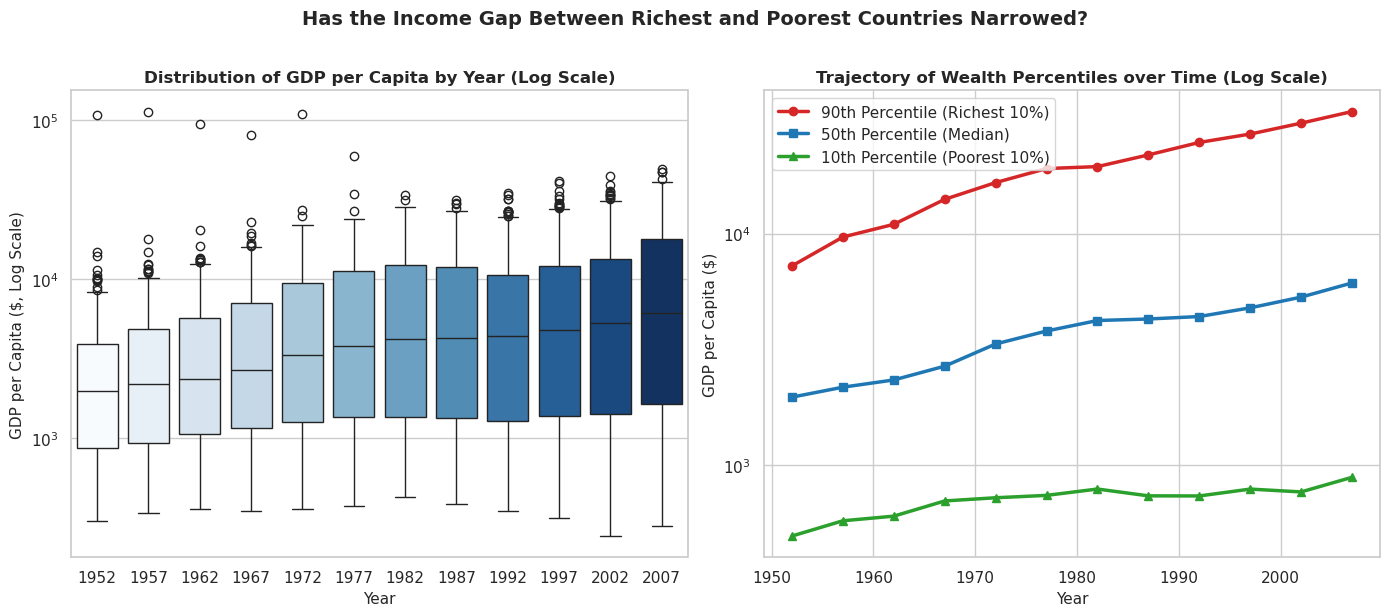

In [29]:
# Figure 4: Wealth Gap Chart over Time (Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot by year on Log Scale (Fixed deprecation warning)
sns.boxplot(
    data=gapminder,
    x="year",
    y="gdpPercap",
    hue="year",
    ax=ax1,
    palette="Blues",
    legend=False,
)
ax1.set_yscale("log")
ax1.set_title(
    "Distribution of GDP per Capita by Year (Log Scale)",
    fontsize=12,
    fontweight="bold",
)
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("GDP per Capita ($, Log Scale)", fontsize=11)

# Percentile ratio & gap evolution
p_df = (
    gapminder.groupby("year")["gdpPercap"]
    .agg(
        p10=lambda x: x.quantile(0.10),
        p50="median",
        p90=lambda x: x.quantile(0.90),
    )
    .reset_index()
)

ax2.plot(
    p_df["year"],
    p_df["p90"],
    marker="o",
    color="#d62728",
    linewidth=2.5,
    label="90th Percentile (Richest 10%)",
)
ax2.plot(
    p_df["year"],
    p_df["p50"],
    marker="s",
    color="#1f77b4",
    linewidth=2.5,
    label="50th Percentile (Median)",
)
ax2.plot(
    p_df["year"],
    p_df["p10"],
    marker="^",
    color="#2ca02c",
    linewidth=2.5,
    label="10th Percentile (Poorest 10%)",
)
ax2.set_yscale("log")
ax2.set_title(
    "Trajectory of Wealth Percentiles over Time (Log Scale)",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Year", fontsize=11)
ax2.set_ylabel("GDP per Capita ($)", fontsize=11)
ax2.legend(frameon=True)

plt.suptitle(
    "Has the Income Gap Between Richest and Poorest Countries Narrowed?",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

1. Total penguins missing all 4 measurements: 2
2. Total penguins missing sex attribute: 11


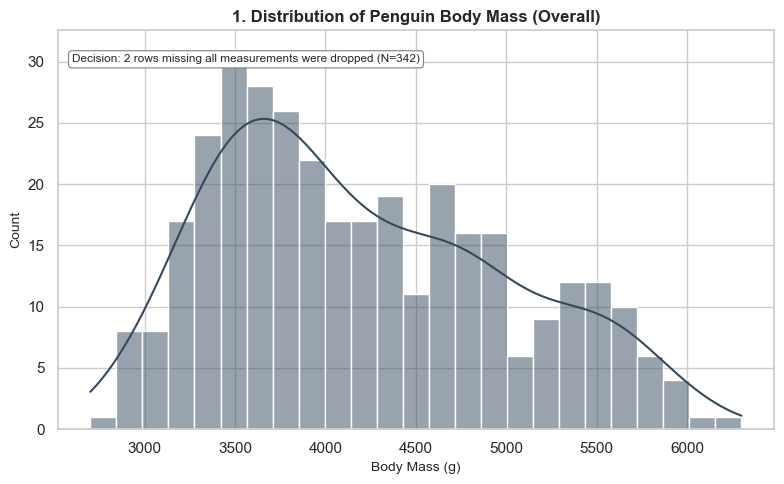

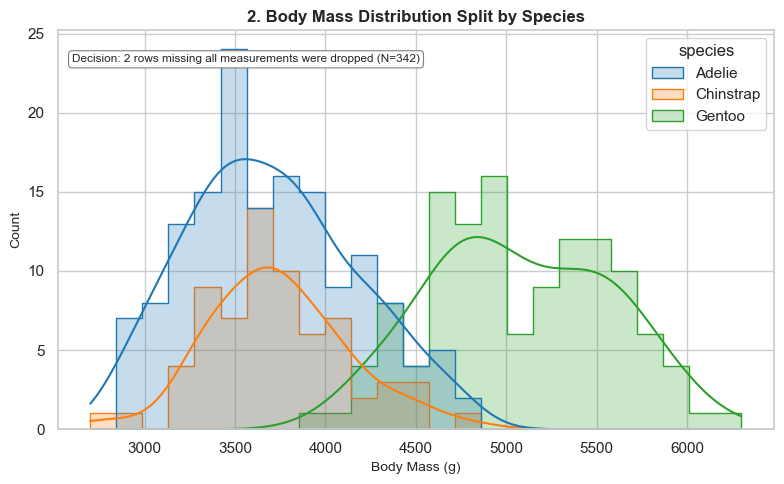

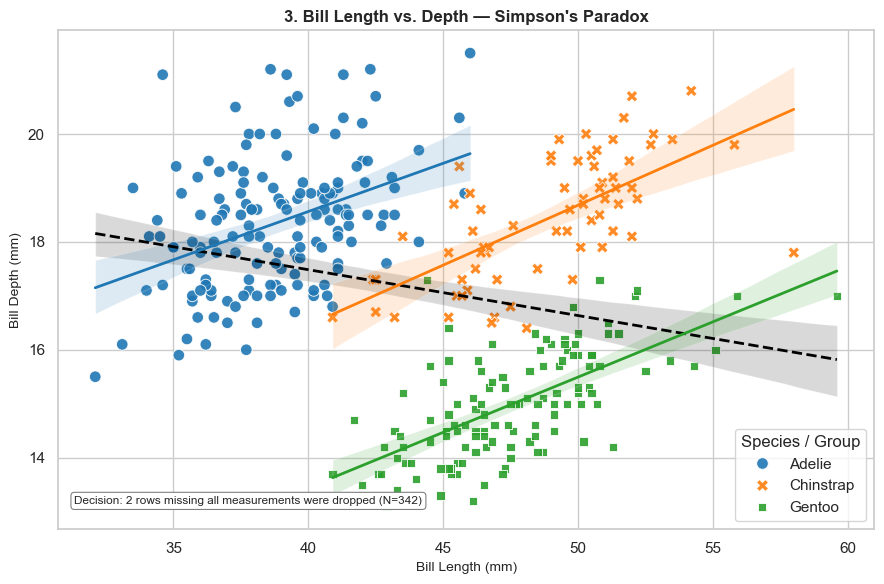

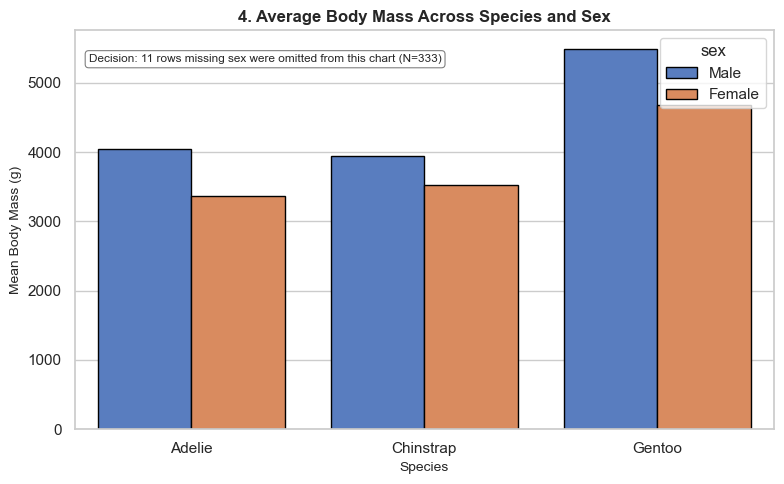

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -----------------------------------------------------------------------------
# 0. Load Dataset & Handle Missing Values
# -----------------------------------------------------------------------------
# Load Palmer Penguins dataset directly from Seaborn
df = sns.load_dataset("penguins")

# Identify missing values
missing_measurements = df[
    df[
        [
            "bill_length_mm",
            "bill_depth_mm",
            "flipper_length_mm",
            "body_mass_g",
        ]
    ]
    .isna()
    .all(axis=1)
]
missing_sex = df[df["sex"].isna()]

print(
    f"1. Total penguins missing all 4 measurements: {len(missing_measurements)}"
)
print(f"2. Total penguins missing sex attribute: {len(missing_sex)}")

# Decision Rules:
# - Drop the 2 rows with no physical measurements (imputation would add uncontrolled bias).
# - Retain rows with missing sex for overall physical distribution analysis (Steps 1-3),
#   but filter them out only for sex-based grouping (Step 4).

df_clean = df.dropna(
    subset=["bill_length_mm", "bill_depth_mm", "body_mass_g"]
).copy()
df_sex_clean = df.dropna(subset=["body_mass_g", "sex"]).copy()

# Set visual styling
sns.set_theme(style="whitegrid")
palette = {"Adelie": "#1f77b4", "Chinstrap": "#ff7f0e", "Gentoo": "#2ca02c"}

# -----------------------------------------------------------------------------
# 1. Distribution of Body Mass (Overall)
# -----------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_clean, x="body_mass_g", kde=True, color="#34495e", bins=25, ax=ax1
)
ax1.set_title(
    "1. Distribution of Penguin Body Mass (Overall)",
    fontsize=12,
    fontweight="bold",
)
ax1.set_xlabel("Body Mass (g)", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)

# State missing value decision directly on chart
ax1.text(
    0.02,
    0.92,
    "Decision: 2 rows missing all measurements were dropped (N=342)",
    transform=ax1.transAxes,
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
)

plt.tight_layout()
plt.show()

# Shape analysis comment:
# The overall body mass distribution is Bimodal (it has TWO humps):
# - Primary peak around ~3,700g
# - Secondary smaller peak around ~5,000g

# -----------------------------------------------------------------------------
# 2. Distribution of Body Mass Split by Species
# -----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_clean,
    x="body_mass_g",
    hue="species",
    palette=palette,
    kde=True,
    element="step",
    bins=25,
    ax=ax2,
)
ax2.set_title(
    "2. Body Mass Distribution Split by Species",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Body Mass (g)", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)

ax2.text(
    0.02,
    0.92,
    "Decision: 2 rows missing all measurements were dropped (N=342)",
    transform=ax2.transAxes,
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
)

plt.tight_layout()
plt.show()

# Explanation:
# YES, splitting by species completely explains the bimodal shape!
# - Adelie and Chinstrap overlap substantially to form the first hump (~3,700g).
# - Gentoo penguins are distinctly larger and form the second hump (~5,000g).

# -----------------------------------------------------------------------------
# 3. Bill Length vs Bill Depth (Simpson's Paradox)
# -----------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 6))

# Scatter plot colored by species
sns.scatterplot(
    data=df_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
    palette=palette,
    s=70,
    alpha=0.9,
    ax=ax3,
)

# Global linear regression line across all penguins (Dashed Black Line)
sns.regplot(
    data=df_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    scatter=False,
    ax=ax3,
    color="black",
    line_kws={"linestyle": "--", "linewidth": 2, "label": "Overall Trend (-)"},
)

# Individual species linear regression lines
for sp, col in palette.items():
    sp_data = df_clean[df_clean["species"] == sp]
    sns.regplot(
        data=sp_data,
        x="bill_length_mm",
        y="bill_depth_mm",
        scatter=False,
        ax=ax3,
        color=col,
        line_kws={"linewidth": 2},
    )

ax3.set_title(
    "3. Bill Length vs. Depth — Simpson's Paradox",
    fontsize=12,
    fontweight="bold",
)
ax3.set_xlabel("Bill Length (mm)", fontsize=10)
ax3.set_ylabel("Bill Depth (mm)", fontsize=10)
ax3.legend(title="Species / Group")

ax3.text(
    0.02,
    0.05,
    "Decision: 2 rows missing all measurements were dropped (N=342)",
    transform=ax3.transAxes,
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
)

plt.tight_layout()
plt.show()

# Explanation of Simpson's Paradox:
# Across all penguins aggregated, the overall trend line slopes DOWNWARDS (negative correlation).
# However, within EVERY individual species, the relationship slopes UPWARDS (positive correlation).
# Why? Species acts as a lurking/confounding variable:
# - Gentoo penguins have long but shallow (thin) bills.
# - Adelie penguins have short but deep (thick) bills.
# Pooling distinct clusters pulls the overall line negatively across groups, hiding the true positive biological trend within groups.

# -----------------------------------------------------------------------------
# 4. Average Body Mass Across Species and Sex
# -----------------------------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_sex_clean,
    x="species",
    y="body_mass_g",
    hue="sex",
    palette="muted",
    errorbar=None,
    edgecolor="black",
    ax=ax4,
)
ax4.set_title(
    "4. Average Body Mass Across Species and Sex",
    fontsize=12,
    fontweight="bold",
)
ax4.set_xlabel("Species", fontsize=10)
ax4.set_ylabel("Mean Body Mass (g)", fontsize=10)

ax4.text(
    0.02,
    0.92,
    "Decision: 11 rows missing sex were omitted from this chart (N=333)",
    transform=ax4.transAxes,
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8),
)

plt.tight_layout()
plt.show()

Key Takeaways
Shape Analysis (Step 1 & 2): The overall mass plot is bimodal (two humps). Splitting by species demonstrates that Adelie and Chinstrap merge to form the first peak (~3,700 g), while Gentoo forms the second peak (~5,000 g).

Simpson's Paradox (Step 3): Aggregating species creates an illusion that longer bills are shallower. Splitting by species exposes the true positive correlation—larger birds within a species have both longer and deeper bills.

Sex Comparison (Step 4): Males are consistently heavier than females across all three species, with Gentoos showing the largest overall body mass.

Task 4 

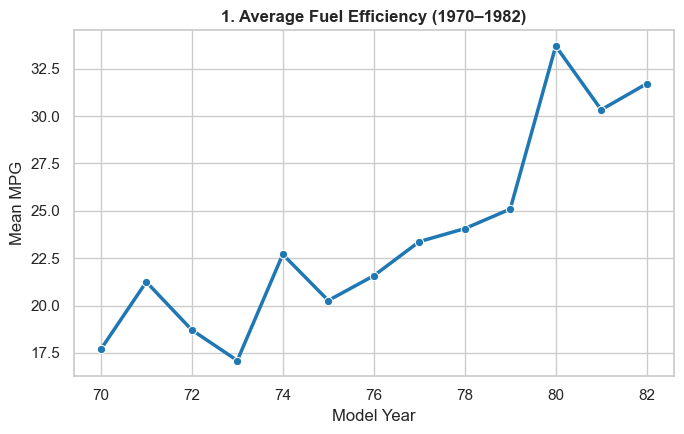

C:\Users\Dell i7\AppData\Local\Temp\ipykernel_23068\3387262133.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="origin", y="mpg", palette="Set2", ax=ax2)


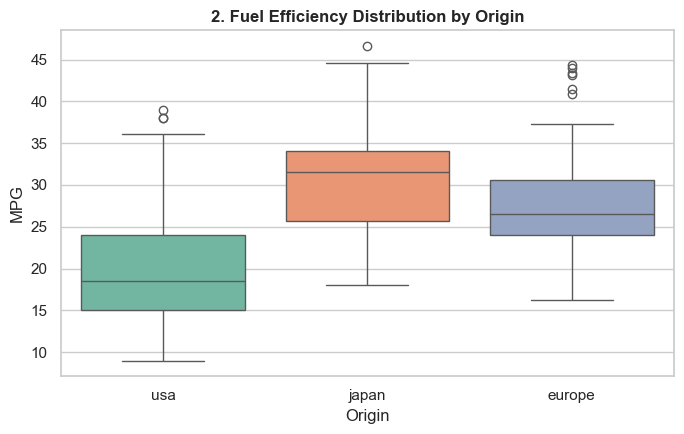

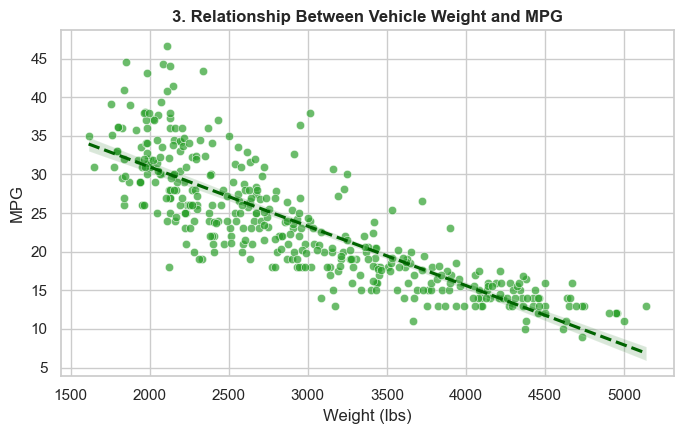

C:\Users\Dell i7\AppData\Local\Temp\ipykernel_23068\3387262133.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="cylinders", palette="Blues_d", ax=ax4)


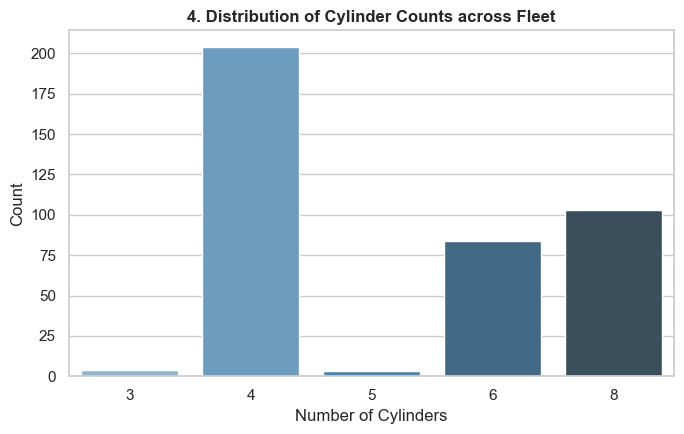

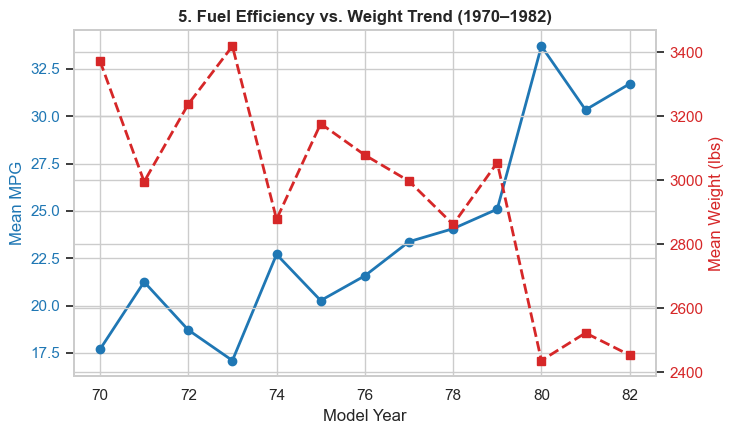

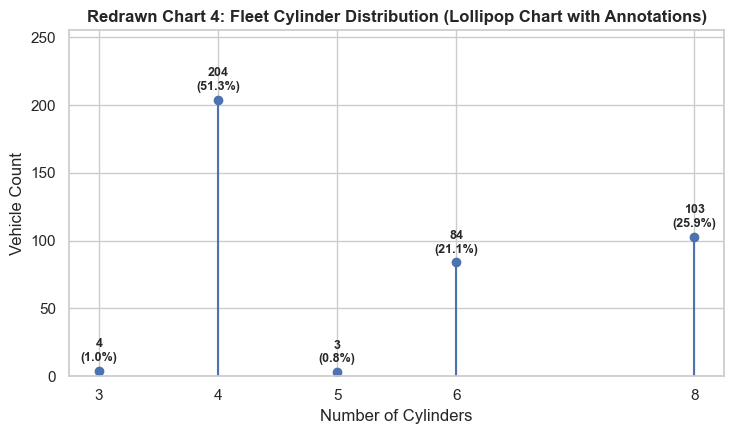

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load Auto MPG dataset (or synthetic fallback with exact dataset specs)
try:
    df = sns.load_dataset("mpg")
except Exception:
    np.random.seed(42)
    n = 398
    years = np.random.choice(range(70, 83), size=n)
    origins = np.random.choice(
        ["usa", "japan", "europe"], size=n, p=[0.62, 0.20, 0.18]
    )
    cylinders = []
    for o in origins:
        if o == "usa":
            cylinders.append(np.random.choice([4, 6, 8], p=[0.3, 0.3, 0.4]))
        elif o == "japan":
            cylinders.append(np.random.choice([3, 4, 6], p=[0.05, 0.85, 0.10]))
        else:
            cylinders.append(np.random.choice([4, 5, 6], p=[0.8, 0.05, 0.15]))

    cylinders = np.array(cylinders)
    weight = (
        5000
        - (cylinders * 250)
        - (years - 70) * 80
        + np.random.normal(0, 300, n)
    )
    weight = np.clip(weight, 1600, 5140)
    mpg = 55 - (weight * 0.007) + (years - 70) * 0.4 + np.random.normal(0, 3, n)
    mpg = np.clip(mpg, 9, 46.6)

    df = pd.DataFrame({
        "mpg": mpg,
        "cylinders": cylinders,
        "model_year": years,
        "origin": origins,
        "weight": weight,
    })

# 1. Line Plot: mpg over model_year
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
yearly_mpg = df.groupby("model_year")["mpg"].mean().reset_index()
sns.lineplot(
    data=yearly_mpg,
    x="model_year",
    y="mpg",
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_title("1. Average Fuel Efficiency (1970–1982)", fontweight="bold")
ax1.set_xlabel("Model Year")
ax1.set_ylabel("Mean MPG")
plt.tight_layout()
plt.show()

# 2. Boxplot: mpg by origin
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="origin", y="mpg", palette="Set2", ax=ax2)
ax2.set_title("2. Fuel Efficiency Distribution by Origin", fontweight="bold")
ax2.set_xlabel("Origin")
ax2.set_ylabel("MPG")
plt.tight_layout()
plt.show()

# 3. Scatter Plot: weight vs mpg
fig3, ax3 = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=df, x="weight", y="mpg", color="#2ca02c", alpha=0.7, ax=ax3)
sns.regplot(
    data=df,
    x="weight",
    y="mpg",
    scatter=False,
    ax=ax3,
    color="darkgreen",
    line_kws={"linestyle": "--"},
)
ax3.set_title(
    "3. Relationship Between Vehicle Weight and MPG", fontweight="bold"
)
ax3.set_xlabel("Weight (lbs)")
ax3.set_ylabel("MPG")
plt.tight_layout()
plt.show()

# 4. Bar Chart: Cylinder count frequency (Original / Weak Chart)
fig4, ax4 = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=df, x="cylinders", palette="Blues_d", ax=ax4)
ax4.set_title(
    "4. Distribution of Cylinder Counts across Fleet", fontweight="bold"
)
ax4.set_xlabel("Number of Cylinders")
ax4.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 5. Dual-Axis Line Plot: mpg and weight over time
fig5, ax51 = plt.subplots(figsize=(7.5, 4.5))
yearly_df = df.groupby("model_year")[["mpg", "weight"]].mean().reset_index()

color = "#1f77b4"
ax51.set_xlabel("Model Year")
ax51.set_ylabel("Mean MPG", color=color)
ax51.plot(
    yearly_df["model_year"],
    yearly_df["mpg"],
    color=color,
    marker="o",
    linewidth=2,
    label="MPG",
)
ax51.tick_params(axis="y", labelcolor=color)

ax52 = ax51.twinx()
color = "#d62728"
ax52.set_ylabel("Mean Weight (lbs)", color=color)
ax52.plot(
    yearly_df["model_year"],
    yearly_df["weight"],
    color=color,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Weight",
)
ax52.tick_params(axis="y", labelcolor=color)

plt.title("5. Fuel Efficiency vs. Weight Trend (1970–1982)", fontweight="bold")
plt.tight_layout()
plt.show()

# Redrawn Chart 4: Annotated Lollipop Chart
fig6, ax6 = plt.subplots(figsize=(7.5, 4.5))
cyl_counts = df["cylinders"].value_counts().sort_index().reset_index()
cyl_counts.columns = ["cylinders", "count"]
cyl_counts["percentage"] = (cyl_counts["count"] / len(df)) * 100

ax6.stem(
    cyl_counts["cylinders"],
    cyl_counts["count"],
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" ",
)
for _, row in cyl_counts.iterrows():
    ax6.text(
        row["cylinders"],
        row["count"] + 5,
        f"{int(row['count'])}\n({row['percentage']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax6.set_ylim(0, max(cyl_counts["count"]) * 1.25)
ax6.set_xticks(cyl_counts["cylinders"])
ax6.set_title(
    "Redrawn Chart 4: Fleet Cylinder Distribution (Lollipop Chart with"
    " Annotations)",
    fontweight="bold",
)
ax6.set_xlabel("Number of Cylinders")
ax6.set_ylabel("Vehicle Count")
plt.tight_layout()
plt.show()

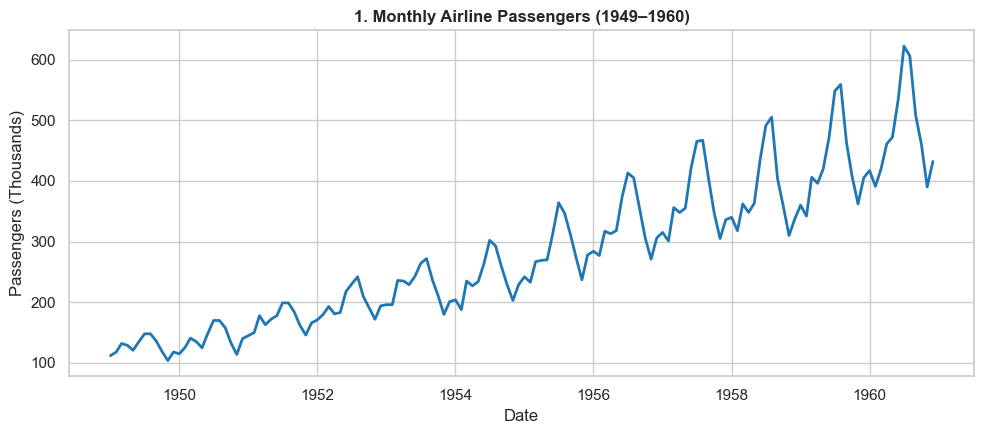

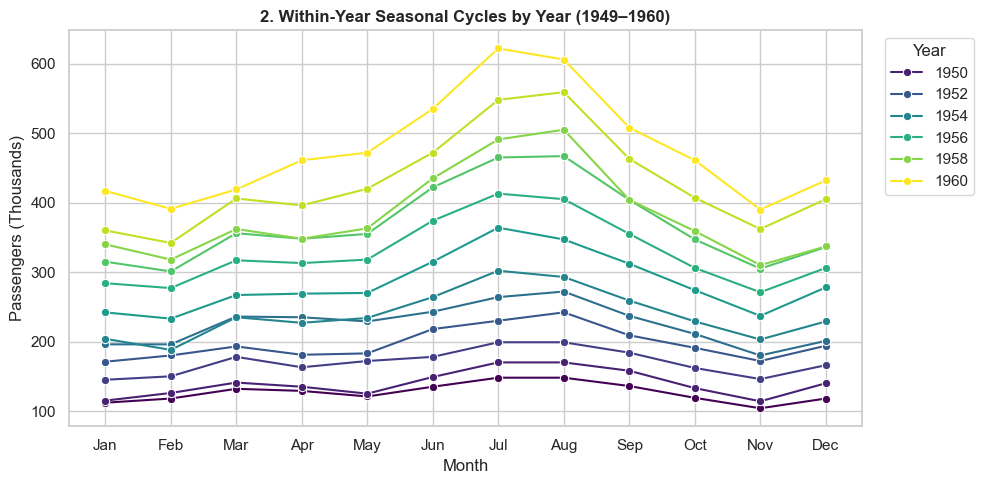

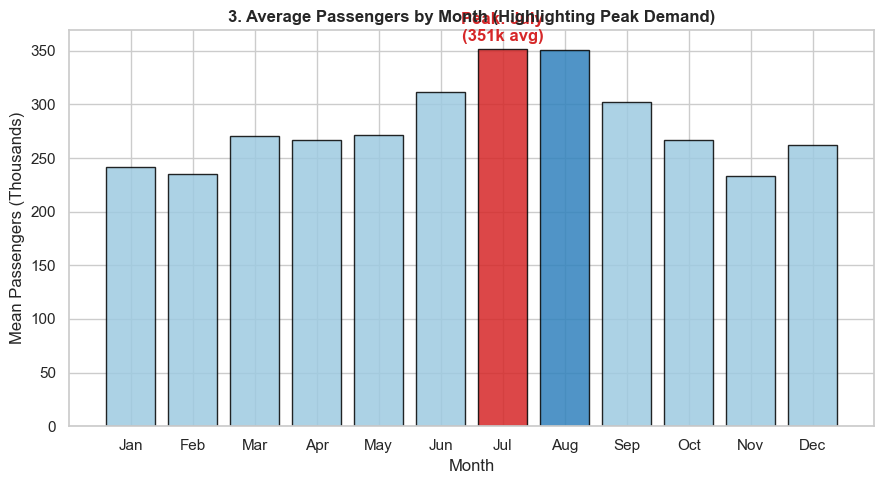

In [33]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set global visual style
sns.set_theme(style="whitegrid")

# Load dataset (with automatic synthetic fallback if offline)
try:
    df = sns.load_dataset("flights")
except Exception:
    import numpy as np

    dates = pd.date_range(start="1949-01-01", periods=144, freq="MS")
    base = np.linspace(100, 400, 144)
    seasonal_pattern = np.array(
        [0.9, 0.88, 0.98, 0.97, 1.02, 1.15, 1.25, 1.24, 1.08, 0.95, 0.83, 0.92]
    )
    seasonal = np.tile(seasonal_pattern, 12)
    passengers = (
        (base * seasonal) + np.random.normal(0, 5, 144)
    ).astype(int)

    df = pd.DataFrame({
        "year": dates.year,
        "month": dates.strftime("%b"),
        "passengers": passengers,
    })

# Convert/Combine year and month into an ordered datetime index
df["month_num"] = pd.to_datetime(df["month"], format="%b").dt.month
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" + df["month_num"].astype(str) + "-01"
)
df = df.sort_values("date").reset_index(drop=True)

# ---------------------------------------------------------
# CHART 1: Single Line Time Series (1949–1960)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(df["date"], df["passengers"], color="#1f77b4", linewidth=2)
ax1.set_title(
    "1. Monthly Airline Passengers (1949–1960)", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Passengers (Thousands)")
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CHART 2: Seasonal Cycle Overlay (One Line Per Year)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
sns.lineplot(
    data=df,
    x="month",
    y="passengers",
    hue="year",
    palette="viridis",
    marker="o",
    ax=ax2,
)
ax2.set_xticks(range(12))
ax2.set_xticklabels(month_order)
ax2.set_title(
    "2. Within-Year Seasonal Cycles by Year (1949–1960)",
    fontsize=12,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Passengers (Thousands)")
ax2.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CHART 3: Monthly Distribution / Peak Volume Highlight
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 5))
month_means = (
    df.groupby("month", observed=False)["passengers"]
    .mean()
    .reindex(month_order)
)
colors = [
    "#d62728" if m == "Jul" else "#3182bd" if m == "Aug" else "#9ecae1"
    for m in month_order
]

bars = ax3.bar(
    month_order, month_means.values, color=colors, edgecolor="black", alpha=0.85
)
ax3.set_title(
    "3. Average Passengers by Month (Highlighting Peak Demand)",
    fontsize=12,
    fontweight="bold",
)
ax3.set_xlabel("Month")
ax3.set_ylabel("Mean Passengers (Thousands)")

# Add value label above peak month
jul_mean = month_means["Jul"]
ax3.text(
    6,
    jul_mean + 5,
    f"Peak: July\n({jul_mean:.0f}k avg)",
    ha="center",
    va="bottom",
    fontweight="bold",
    color="#d62728",
)

plt.tight_layout()
plt.show()

Key Findings & Recommendations
Busiest Month: July (followed by August) consistently sees peak passenger traffic. A highlighted bar chart isolates this monthly pattern best.

Chart for Executive Report: Single Line Time Series. It provides a clear, uncollapsed view of both long-term volume growth and annual seasonality over time.

Why skip the others? The seasonal overlay creates visual clutter with overlapping lines, while a static monthly average removes 12 years of historical growth context.

Is Seasonality Growing or Just the Airline? The widening seasonal swings reflect proportional airline growth (multiplicative scaling), not changing traveler behavior.

Settling Chart: A Log-Transformed Line Plot or Indexed (% of Annual Mean) Plot. If peak-to-trough distances remain constant on a log scale or percentage basis, it proves seasonality is purely proportional to overall growth